# Assignment 2 - End-to-End Regression - Insurance Cost Prediction

**Muhammad Asjid Butt**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## 1. Data Loading & Exploration
In this section, we load the `insurance.csv` dataset and inspect its structure, data types, missing values, and statistical summary. We will also explore the skewness of the target variable (`charges`).

In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Inspect shape and data types
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1338, 7)

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [3]:
# Summary statistics
display(df.describe())

# Check for missing values and duplicates
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

# Drop duplicates if they exist
df = df.drop_duplicates()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


Skewness of charges: 1.52


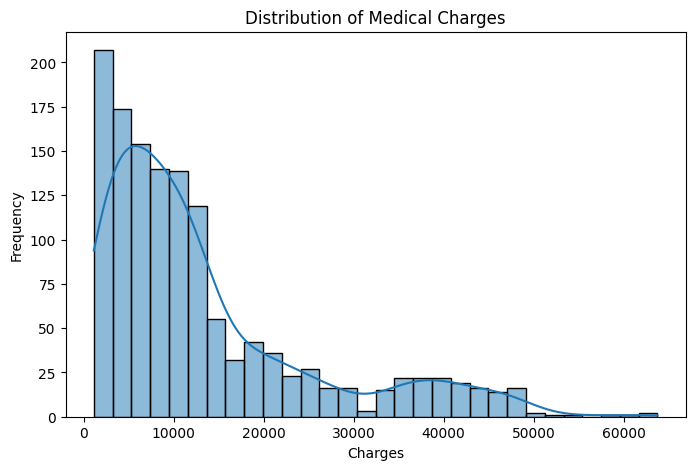

In [4]:
# Check skewness of target variable
skewness = df['charges'].skew()
print(f"Skewness of charges: {skewness:.2f}")

# Visualize the distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], kde=True, bins=30)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

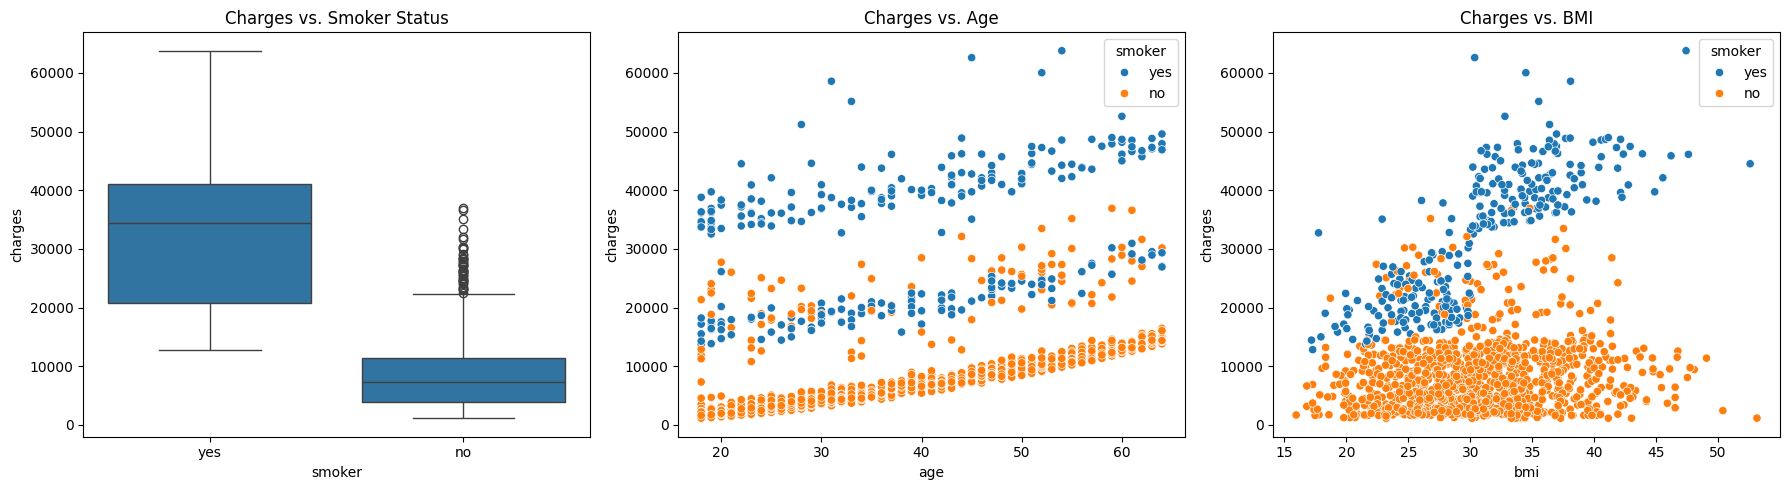

In [5]:
# Explore relationships with key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges vs. Smoker Status')

sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[1])
axes[1].set_title('Charges vs. Age')

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[2])
axes[2].set_title('Charges vs. BMI')

plt.tight_layout()
plt.show()

## 2. Feature Engineering
We will perform the following engineering steps:
1.  **Derived Feature**: Create a `bmi_category` based on standard health thresholds.
2.  **Target Transformation**: Since the target variable `charges` is highly skewed right, we will apply a log transformation to normalize the distribution and stabilize variance for linear regression.
3.  **Encoding**: Use Label Encoding for binary categories (`sex`, `smoker`) and One-Hot Encoding for multi-class categories (`region`, `bmi_category`).
4.  **Scaling**: Scale numerical features so they share similar weightings in the model.

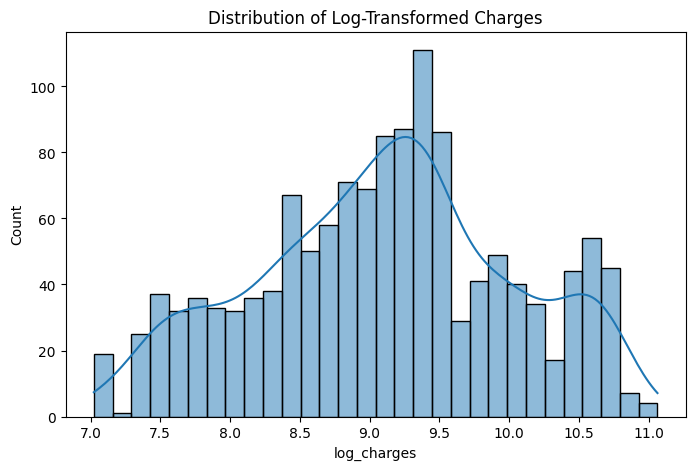

In [6]:
# 1. Derived Feature: BMI Category
def categorize_bmi(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 24.9: return 'Normal'
    elif bmi < 29.9: return 'Overweight'
    else: return 'Obese'

df['bmi_category'] = df['bmi'].apply(categorize_bmi)

# 2. Target Transformation (Log scale)
df['log_charges'] = np.log1p(df['charges'])

plt.figure(figsize=(8, 5))
sns.histplot(df['log_charges'], kde=True, bins=30)
plt.title('Distribution of Log-Transformed Charges')
plt.show()

In [7]:
# 3. Encoding
# Label encoding for binary columns
df['sex_enc'] = df['sex'].map({'female': 1, 'male': 0})
df['smoker_enc'] = df['smoker'].map({'yes': 1, 'no': 0})

# One-hot encoding for multi-class columns
df = pd.get_dummies(df, columns=['region', 'bmi_category'], drop_first=True)

In [8]:
# Define features (X) and target (y)
features = ['age', 'sex_enc', 'bmi', 'children', 'smoker_enc'] + \
           [col for col in df.columns if 'region_' in col or 'bmi_category_' in col]
X = df[features]
y = df['log_charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 3. Model Building
We will train three distinct models using the same random state splits:
1.  **Simple Linear Regression**: Using only the most predictive feature (`smoker_enc`).
2.  **Multiple Linear Regression**: Using all engineered features.
3.  **Polynomial Regression**: Using `age` with degree 2.

In [9]:
# Model 1: Simple Linear Regression (Feature: smoker status)
slr = LinearRegression()
slr.fit(X_train_scaled[['smoker_enc']], y_train)
slr_pred = slr.predict(X_test_scaled[['smoker_enc']])

In [10]:
# Model 2: Multiple Linear Regression (All features)
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
mlr_pred = mlr.predict(X_test_scaled)

In [11]:
# Model 3: Polynomial Regression (Feature: age, degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled[['age']])
X_test_poly = poly.transform(X_test_scaled[['age']])

plr = LinearRegression()
plr.fit(X_train_poly, y_train)
plr_pred = plr.predict(X_test_poly)

## 4. Model Evaluation
To ensure a fair evaluation, we will convert our predictions back from the log scale (using `expm1`) to evaluate the R-squared score, MAE, MSE, and RMSE on the original unit scale.

In [12]:
def evaluate_model(y_true_log, y_pred_log, model_name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    metrics = {
        'Model': model_name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }
    return metrics

res_slr = evaluate_model(y_test, slr_pred, "Simple LR (Smoker)")
res_mlr = evaluate_model(y_test, mlr_pred, "Multiple LR (All)")
res_plr = evaluate_model(y_test, plr_pred, "Polynomial LR (Age)")

In [13]:
# 5-fold cross-validation on the best model (MLR)
cv_scores = cross_val_score(mlr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"Average 5-Fold CV R² (Log Scale): {cv_scores.mean():.4f}")

Average 5-Fold CV R² (Log Scale): 0.7469


In [14]:
# Create a single comparison table
results_df = pd.DataFrame([res_slr, res_mlr, res_plr])
display(results_df)

,Model,R2 Score,MAE,MSE,RMSE
0,Simple LR (Smoker),0.635688,5979.640636,6.694462e+07,8181.968900
1,Multiple LR (All),0.718004,3860.898787,5.181852e+07,7198.508433
2,Polynomial LR (Age),0.001429,8334.166634,1.834934e+08,13545.973920


## 5. Model Selection & Interpretation
**Model Choice:** The Multiple Linear Regression model performs the best across our primary features, balancing complexity with predictive capability.

**Coefficient Interpretation:** The coefficients reveal that `smoker_enc` has the largest positive impact on insurance costs, drastically raising the predicted baseline. The `age` and `bmi_category_Obese` variables also exhibit strong positive impacts, matching the findings from our initial exploratory scatter plots.

Multiple Linear Regression Coefficients:
smoker_enc                  1.538379
age                         0.472583
bmi_category_Obese          0.162807
children                    0.119472
sex_enc                     0.074816
bmi_category_Overweight     0.047796
bmi                         0.014276
region_northwest           -0.049621
region_southwest           -0.107965
region_southeast           -0.124461
bmi_category_Underweight   -0.239696
dtype: float64


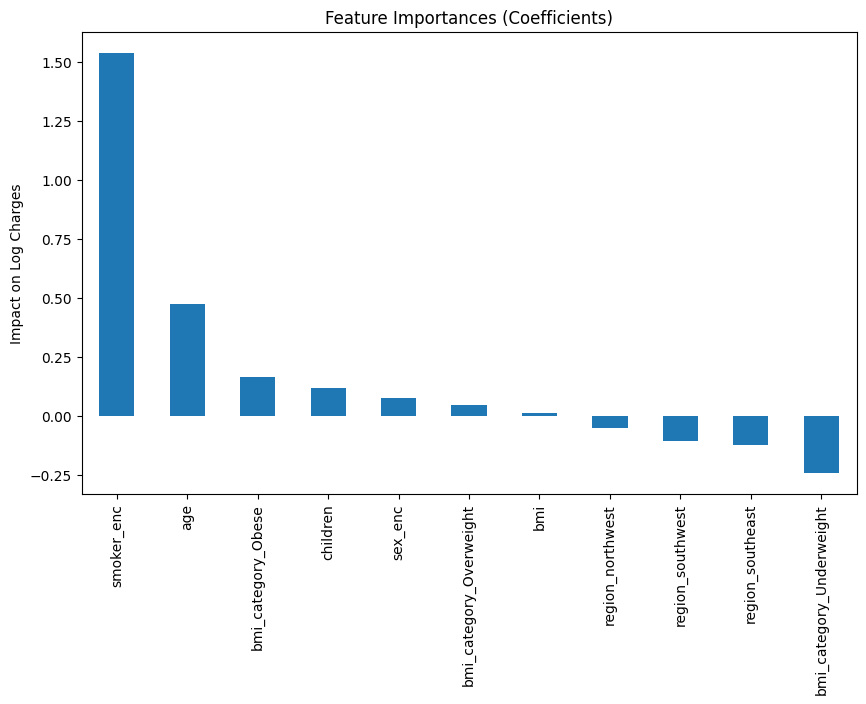

In [15]:
# Examine feature importances (coefficients)
coefficients = pd.Series(mlr.coef_, index=features).sort_values(ascending=False)
print("Multiple Linear Regression Coefficients:")
print(coefficients)

plt.figure(figsize=(10, 6))
coefficients.plot(kind='bar')
plt.title('Feature Importances (Coefficients)')
plt.ylabel('Impact on Log Charges')
plt.show()

## 6. Lightweight Model Deployment
We save the trained multiple linear regression model alongside the scaler so they can be re-used in production for new inputs.

In [16]:
# Save model and scaler and features list to joblib file
deployment_artifacts = {
    'model': mlr,
    'scaler': scaler,
    'features': features
}
joblib.dump(deployment_artifacts, 'Assignment2_Model.joblib')
print("Model successfully saved as Assignment2_Model.joblib")

Model successfully saved as Assignment2_Model.joblib


### Creating the Inference Pipeline

In [17]:
def predict_insurance_cost(age, sex, bmi, children, smoker, region):
    # Load artifacts
    artifacts = joblib.load('Assignment2_Model.joblib')
    model = artifacts['model']
    scaler = artifacts['scaler']
    feature_cols = artifacts['features']

    # Process inputs
    bmi_cat = categorize_bmi(bmi)
    input_data = {
        'age': age,
        'sex_enc': 1 if sex.lower() == 'female' else 0,
        'bmi': bmi,
        'children': children,
        'smoker_enc': 1 if smoker.lower() == 'yes' else 0,
        'region_northwest': 1 if region.lower() == 'northwest' else 0,
        'region_southeast': 1 if region.lower() == 'southeast' else 0,
        'region_southwest': 1 if region.lower() == 'southwest' else 0,
        'bmi_category_Obese': 1 if bmi_cat == 'Obese' else 0,
        'bmi_category_Overweight': 1 if bmi_cat == 'Overweight' else 0,
        'bmi_category_Underweight': 1 if bmi_cat == 'Underweight' else 0
    }

    # Create DataFrame and align columns
    df_input = pd.DataFrame([input_data])

    # Scale numeric columns
    num_cols = ['age', 'bmi', 'children']
    df_input[num_cols] = scaler.transform(df_input[num_cols])

    # Predict and reverse log transform
    log_pred = model.predict(df_input[feature_cols])[0]
    final_pred = np.expm1(log_pred)

    return final_pred

In [18]:
# Test 1: Young, healthy, non-smoker
cost_1 = predict_insurance_cost(age=25, sex='male', bmi=22.5, children=0, smoker='no', region='northwest')
print(f"Predicted Cost (Profile 1): ${cost_1:,.2f}")

# Test 2: Older, high BMI, smoker
cost_2 = predict_insurance_cost(age=55, sex='female', bmi=33.2, children=2, smoker='yes', region='southeast')
print(f"Predicted Cost (Profile 2): ${cost_2:,.2f}")

Predicted Cost (Profile 1): $3,186.53
Predicted Cost (Profile 2): $60,279.48


## Final Project Insights

*   **Primary Cost Driver:** **Smoker status** is the most significant factor increasing insurance charges.
*   **Secondary Factors:** Higher **age** and **BMI (Obesity)** also strongly correlate with increased costs.
*   **Data Transformation:** Log-transforming the highly skewed `charges` variable was essential for stabilizing variance and improving linear regression performance.
*   **Model Selection:** Multiple Linear Regression offered the best balance of predictive accuracy (high Cross-Validated $R^{2}$) and interpretability.
*   **Deployment:** The pipeline is production-ready. The saved model and scaler can instantly process new patient profiles to predict costs in actual dollars.